# Model comparison: length scale x speaker rationality

Four models of the Study 9 ratings, crossing two binary choices — is coherence generalization
distance-based (length scale fitted vs pinned flat), and is the RSA speaker rationality inferred
or fixed at the design value 3:

|               | beta = 3 (design)   | beta inferred        |
|---------------|---------------------|----------------------|
| **ls fitted** | `fitted`            | `fitted+beta`        |
| **ls flat**   | `flat`              | `flat+beta`          |

- **fitted / fitted+beta**: `length_scale` from its own posterior — coherence generalizes locally
  in embedding space.
- **flat / flat+beta** (distance-blind null): `length_scale = LS_FLAT` (>> the feature-cloud
  diameter ~0.78), so the kernel is effectively constant — training a region elevates coherence
  UNIFORMLY across the embedding (generalization exists but is not based on embedding distance).

Every model uses its OWN posterior-median parameters, loaded from its own results directory, and
its OWN per-feature linking shapes — SHARED across conditions but PROFILED at that model's theta
from the ratings-free coherence mode (`inference.total_log_lik_free_shapes`). So no model is
handicapped by borrowing another's `(mu_0, sigma, beta)` or linking function.

Comparison metric: summed Laplace marginal likelihood `log Z` (higher = better; the beta-free and
beta-inferred models differ by one parameter, flagged in the table). Predictive check: forward-pass
`E[rating] = pz1*mean_kl + (1-pz1)*mean_nkl` per feature vs the empirical mean, correlated both
pooled across conditions and split per condition.

Source posteriors (fitted-shapes VBMC in each; `ls_samples` is the pinned constant for the flat ones):
- `fitted`      -> `results/study9-vbmc-laplace/` (3-D, beta=3)
- `flat`        -> `results/study9-vbmc-laplace-null/` (2-D, ls=10, beta=3)
- `fitted+beta` -> `results/study9-vbmc-laplace-beta/` (4-D)
- `flat+beta`   -> `results/study9-vbmc-laplace-null-beta/` (3-D, ls=10)

In [1]:
DATA_CSV = '../../data/study9.csv'

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")
import sys
sys.path.insert(0, ".")

import json
import numpy as np
import matplotlib.pyplot as plt

import inference as inf

# Each model: (results subdir, whether beta was inferred). beta=3 models have no
# beta_samples in their npz, so we fall back to the design value BETA_SPEAKER.
# Display order: most -> least flexible (fitted+beta, fitted, flat+beta, flat).
MODEL_SPECS = {
    'fitted+beta': ('study9-vbmc-laplace-beta',      True),
    'fitted':      ('study9-vbmc-laplace',           False),
    'flat+beta':   ('study9-vbmc-laplace-null-beta', True),
    'flat':        ('study9-vbmc-laplace-null',      False),
}
N_PARAMS = {'fitted': 3, 'flat': 2, 'fitted+beta': 4, 'flat+beta': 3}  # free (mu_0,sigma,[ls],[beta])

def _load_median(subdir, beta_inferred):
    z = np.load(os.path.join('results', subdir, 'posterior-fitted-shapes.npz'), allow_pickle=True)
    beta = float(np.median(z['beta_samples'])) if beta_inferred else inf.BETA_SPEAKER
    return {'ls':    float(np.median(z['ls_samples'])),
            'mu_0':  float(np.median(z['mu0_samples'])),
            'sigma': float(np.median(z['sigma_samples'])),
            'beta':  beta,
            'subdir': subdir}

MODELS = {name: _load_median(subdir, bi) for name, (subdir, bi) in MODEL_SPECS.items()}
print(f"{'model':<13}{'ls':>8}{'mu_0':>8}{'sigma':>8}{'beta':>8}{'n_params':>10}")
for name, m in MODELS.items():
    print(f"{name:<13}{m['ls']:>8g}{m['mu_0']:>+8.3f}{m['sigma']:>8.3f}{m['beta']:>8.3f}{N_PARAMS[name]:>10}")

geom = inf.load_geometry()
J = geom['J']
test_feature_names, test_trait = geom['test_feature_names'], geom['test_trait']
responses_cond, _ = inf.load_responses(DATA_CSV)
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
N_cond   = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}

model              ls    mu_0   sigma    beta  n_params
fitted+beta  0.205261  -0.397   0.782  16.035         4
fitted       0.263999  -0.014   0.570   3.000         3
flat+beta          10  +0.008   0.415   3.412         3
flat               10  -0.010   0.412   3.000         2


## Compute: profiled shapes, log Z, and forward-pass predictions per model

For each model, at its own `(ls, mu_0, sigma, beta)`: profile the per-feature linking shapes,
take the per-condition Laplace `log Z`, and run the forward pass to a predicted `E[rating]` per
feature per condition. Everything downstream (tables, plots) reads from `fitres`.

In [2]:
fitres = {}
for name, m in MODELS.items():
    ll, shapes, cond_data = inf.total_log_lik_free_shapes(
        geom, responses_cond, m['ls'], m['mu_0'], m['sigma'],
        beta_speaker=m['beta'], return_shapes=True)
    logZ_c = {c: inf.laplace_log_Z(cond_data[c], m['ls'], m['mu_0'], m['sigma'],
                                   beta_speaker=m['beta'])[0]
              for c in inf.CONDITIONS}
    mean_kl  = shapes[:, 0] / (shapes[:, 0] + shapes[:, 1])
    mean_nkl = shapes[:, 2] / (shapes[:, 2] + shapes[:, 3])
    pred_cond, pz1_cond = {}, {}
    for c in inf.CONDITIONS:
        _, y_hat, _ = inf.laplace_log_Z(cond_data[c], m['ls'], m['mu_0'], m['sigma'],
                                        beta_speaker=m['beta'])
        pz1_cond[c]  = 1.0 / (1.0 + np.exp(-y_hat[:J]))
        pred_cond[c] = pz1_cond[c]*mean_kl + (1-pz1_cond[c])*mean_nkl
    fitres[name] = {'ll': ll, 'logZ_c': logZ_c, 'shapes': shapes,
                    'mean_kl': mean_kl, 'mean_nkl': mean_nkl,
                    'pred_cond': pred_cond, 'pz1_cond': pz1_cond}
    print(f"  {name:<13}: total log Z = {ll:8.1f}")

  fitted+beta  : total log Z =    914.4


  fitted       : total log Z =    907.9


  flat+beta    : total log Z =    901.6


  flat         : total log Z =    901.6


## 1. Log-probability table

Summed Laplace `log Z` (marginal likelihood of the ratings with the coherence field integrated
out) per condition and total, one column per model. `n_params` counts the free GP parameters
(`mu_0`, `sigma`, and `ls` / `beta` where inferred) — the linking shapes are profiled, not
counted, and are treated identically across models. Higher `log Z` = better; a `+1` parameter buys
at most ~`0.5*log(N)` before it's not worth it, so read the deltas against parameter count.

In [3]:
names = list(MODELS)

hdr = f"{'condition':<15}" + "".join(f"{n:>14}" for n in names)
print(hdr); print("-" * len(hdr))
for c in inf.CONDITIONS:
    print(f"{c:<15}" + "".join(f"{fitres[n]['logZ_c'][c]:>14.1f}" for n in names))
print("-" * len(hdr))
print(f"{'TOTAL log Z':<15}" + "".join(f"{fitres[n]['ll']:>14.1f}" for n in names))
print(f"{'n_params':<15}" + "".join(f"{N_PARAMS[n]:>14d}" for n in names))

# deltas vs the simplest model (flat, beta=3)
base = 'flat'
print(f"\nTotal log Z relative to '{base}' (n_params={N_PARAMS[base]}):")
for n in names:
    print(f"  {n:<13}: {fitres[n]['ll']:8.1f}   delta={fitres[n]['ll']-fitres[base]['ll']:+7.1f}"
          f"   (+{N_PARAMS[n]-N_PARAMS[base]} params)")

# AIC-style penalized score (2*n_params - 2*logL) for a quick complexity-aware ranking
print(f"\nAIC-style score (lower=better, 2k - 2*logZ):")
aic = {n: 2*N_PARAMS[n] - 2*fitres[n]['ll'] for n in names}
for n in sorted(names, key=lambda k: aic[k]):
    print(f"  {n:<13}: {aic[n]:8.1f}")

condition         fitted+beta        fitted     flat+beta          flat
-----------------------------------------------------------------------
diet                    200.5         198.8         197.3         197.2
personality             204.0         200.5         193.5         194.1
physical                351.0         349.8         349.2         348.6
heterogeneous           158.9         158.8         161.6         161.8
-----------------------------------------------------------------------
TOTAL log Z             914.4         907.9         901.6         901.6
n_params                    4             3             3             2

Total log Z relative to 'flat' (n_params=2):
  fitted+beta  :    914.4   delta=  +12.8   (+2 params)
  fitted       :    907.9   delta=   +6.3   (+1 params)
  flat+beta    :    901.6   delta=   -0.0   (+1 params)
  flat         :    901.6   delta=   +0.0   (+0 params)

AIC-style score (lower=better, 2k - 2*logZ):
  fitted+beta  :  -1820.8
  fitted  

## 2. Model mean vs empirical mean of prevalence, per feature

Correlation between each model's forward-pass mean prevalence judgment
`E[rating] = pz1*mean_kl + (1-pz1)*mean_nkl` and the empirical mean rating, computed per feature.
Reported **pooled** (all 4 conditions x 15 features = 60 points) and **split per condition**
(15 features each). The forward pass uses each model's own profiled linking shapes, so it reflects
the full model's prediction — not just the raw coherence field.

A caveat for the flat models: within a condition the coherence `pz1` is (near-)constant, so all
of a flat model's per-feature spread comes from the per-feature linking shapes, which absorb each
feature's baseline prevalence. Cross-condition structure (the diagonal in the by-trait heatmap
below) is what actually separates flat from fitted.

r(model E[rating], empirical mean)  per feature

                  fitted+beta        fitted     flat+beta          flat
-----------------------------------------------------------------------
POOLED                 +0.966        +0.961        +0.924        +0.926
-----------------------------------------------------------------------
diet                   +0.975        +0.972        +0.941        +0.942
personality            +0.985        +0.982        +0.955        +0.956
physical               +0.961        +0.953        +0.891        +0.896
heterogeneous          +0.981        +0.977        +0.953        +0.956


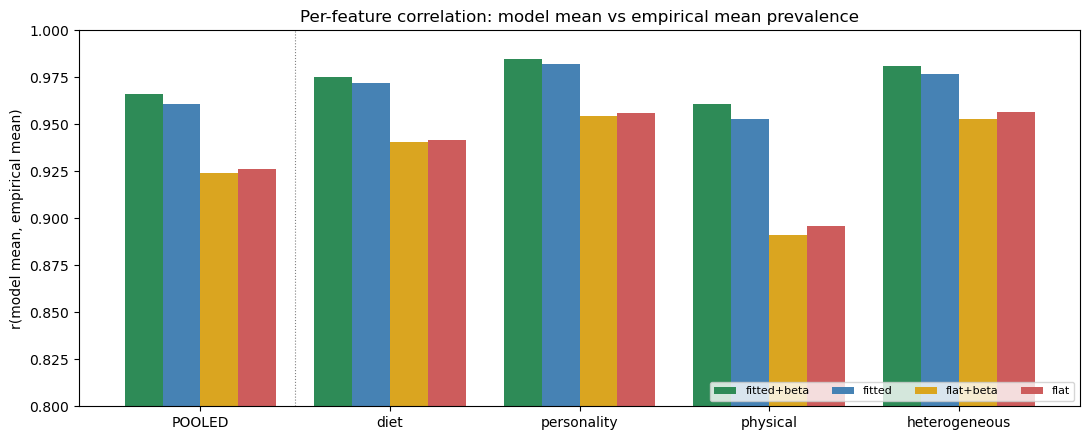

In [4]:
emp_all = np.concatenate([emp_cond[c] for c in inf.CONDITIONS])

def pooled_pred(n):
    return np.concatenate([fitres[n]['pred_cond'][c] for c in inf.CONDITIONS])

r_pool = {n: np.corrcoef(pooled_pred(n), emp_all)[0, 1] for n in names}
r_cond = {n: {c: np.corrcoef(fitres[n]['pred_cond'][c], emp_cond[c])[0, 1] for c in inf.CONDITIONS}
          for n in names}

hdr = f"{'':<15}" + "".join(f"{n:>14}" for n in names)
print("r(model E[rating], empirical mean)  per feature\n")
print(hdr); print("-" * len(hdr))
print(f"{'POOLED':<15}" + "".join(f"{r_pool[n]:>+14.3f}" for n in names))
print("-" * len(hdr))
for c in inf.CONDITIONS:
    print(f"{c:<15}" + "".join(f"{r_cond[n][c]:>+14.3f}" for n in names))

# bar chart: pooled + per-condition correlations, grouped by model
fig, ax = plt.subplots(figsize=(11, 4.5))
groups = ['POOLED'] + list(inf.CONDITIONS)
xg = np.arange(len(groups)); w = 0.8 / len(names)
palette = {'fitted': 'steelblue', 'flat': 'indianred',
           'fitted+beta': 'seagreen', 'flat+beta': 'goldenrod'}
for i, n in enumerate(names):
    vals = [r_pool[n]] + [r_cond[n][c] for c in inf.CONDITIONS]
    ax.bar(xg + (i - (len(names)-1)/2)*w, vals, w, label=n, color=palette.get(n))
ax.set_xticks(xg); ax.set_xticklabels(groups)
ax.set_ylabel('r(model mean, empirical mean)'); ax.set_ylim(0.8, 1.0)
ax.axvline(0.5, color='gray', lw=0.8, ls=':')
ax.set_title('Per-feature correlation: model mean vs empirical mean prevalence')
ax.legend(ncol=4, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

## 3. Coherence fields

Same visualization as `plot-gp-coherence-field.ipynb`, one 2x2 figure per model (16 panels total:
4 models x 4 conditions). ALL panels share ONE color scale, spanning the global min/max across
every field, so color is directly comparable across conditions and across models. Under a flat
model the field is (near-)constant, so its panels are a uniform shade — visibly uniform, which is
the point. Dark points are trained features; outlined points are test features colored by
empirical mean rating on the shared scale. Each figure is saved to its model's results dir.

In [5]:
all_x = np.vstack([np.array(geom['x_test'])] + [np.array(geom['x_train_cond'][c]) for c in inf.CONDITIONS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

# precompute every field (all models x conditions) so all panels share one color scale
fields, pz1_tests = {}, {}
for name, m in MODELS.items():
    for c in inf.CONDITIONS:
        fields[name, c]    = inf.gp_coherence_field(geom, c, m['ls'], m['mu_0'], m['sigma'],
                                                    X_grid, beta_speaker=m['beta']).reshape(gx.shape)
        pz1_tests[name, c] = inf.gp_coherence_field(geom, c, m['ls'], m['mu_0'], m['sigma'],
                                                    x_test_np, beta_speaker=m['beta'])
f_all = np.stack(list(fields.values()))
LEVELS = np.linspace(f_all.min(), f_all.max(), 21)
print(f"shared color scale across all {len(MODELS)} models: [{f_all.min():.3f}, {f_all.max():.3f}]")

def plot_fields(name, m):
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 12))
    for ax, c in zip(axes.ravel(), inf.CONDITIONS):
        field, pz1_test = fields[name, c], pz1_tests[name, c]
        cs = ax.contourf(gx, gy, field, levels=LEVELS, cmap='Blues')
        cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

        x_tr = np.array(geom['x_train_cond'][c])
        ax.scatter(x_tr[:, 0], x_tr[:, 1], s=60, color='#16305e', edgecolor='k',
                   zorder=3, label='train (kind-linked)')
        for (xx, yy), nm in zip(x_tr, geom['train_names_cond'][c]):
            ax.annotate(nm[:12], (xx, yy), fontsize=4, xytext=(2, 3), textcoords='offset points')
        ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=80, c=emp_cond[c], cmap='Blues', norm=cs.norm,
                   edgecolor='k', linewidth=1.2, zorder=3, label='test (mean response)')

        if np.ptp(pz1_test) > 1e-3:
            r_txt = f"r(field @ test, mean rating) = {np.corrcoef(pz1_test, emp_cond[c])[0, 1]:+.2f}"
        else:
            r_txt = 'field ~ constant (r undefined)'
        ax.set_title(f"{c.capitalize()}  (n={N_cond[c]})\n{r_txt}")
        ax.set_xlabel('Embedding Dim 1'); ax.set_ylabel('Embedding Dim 2')
        ax.legend(fontsize=7, loc='upper right')
    fig.suptitle(f"{name.upper()} model -- {m['subdir']}\n"
                 f"ls={m['ls']:g}, mu_0={m['mu_0']:+.3f}, sigma={m['sigma']:.3f}, beta={m['beta']:.3f}   "
                 f"(sum log Z = {fitres[name]['ll']:.1f})", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    out_png = os.path.join('results', m['subdir'], 'gp-coherence-field-comparison.png')
    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    print('saved', out_png)
    plt.show()

shared color scale across all 4 models: [0.402, 0.775]


saved results/study9-vbmc-laplace-beta/gp-coherence-field-comparison.png


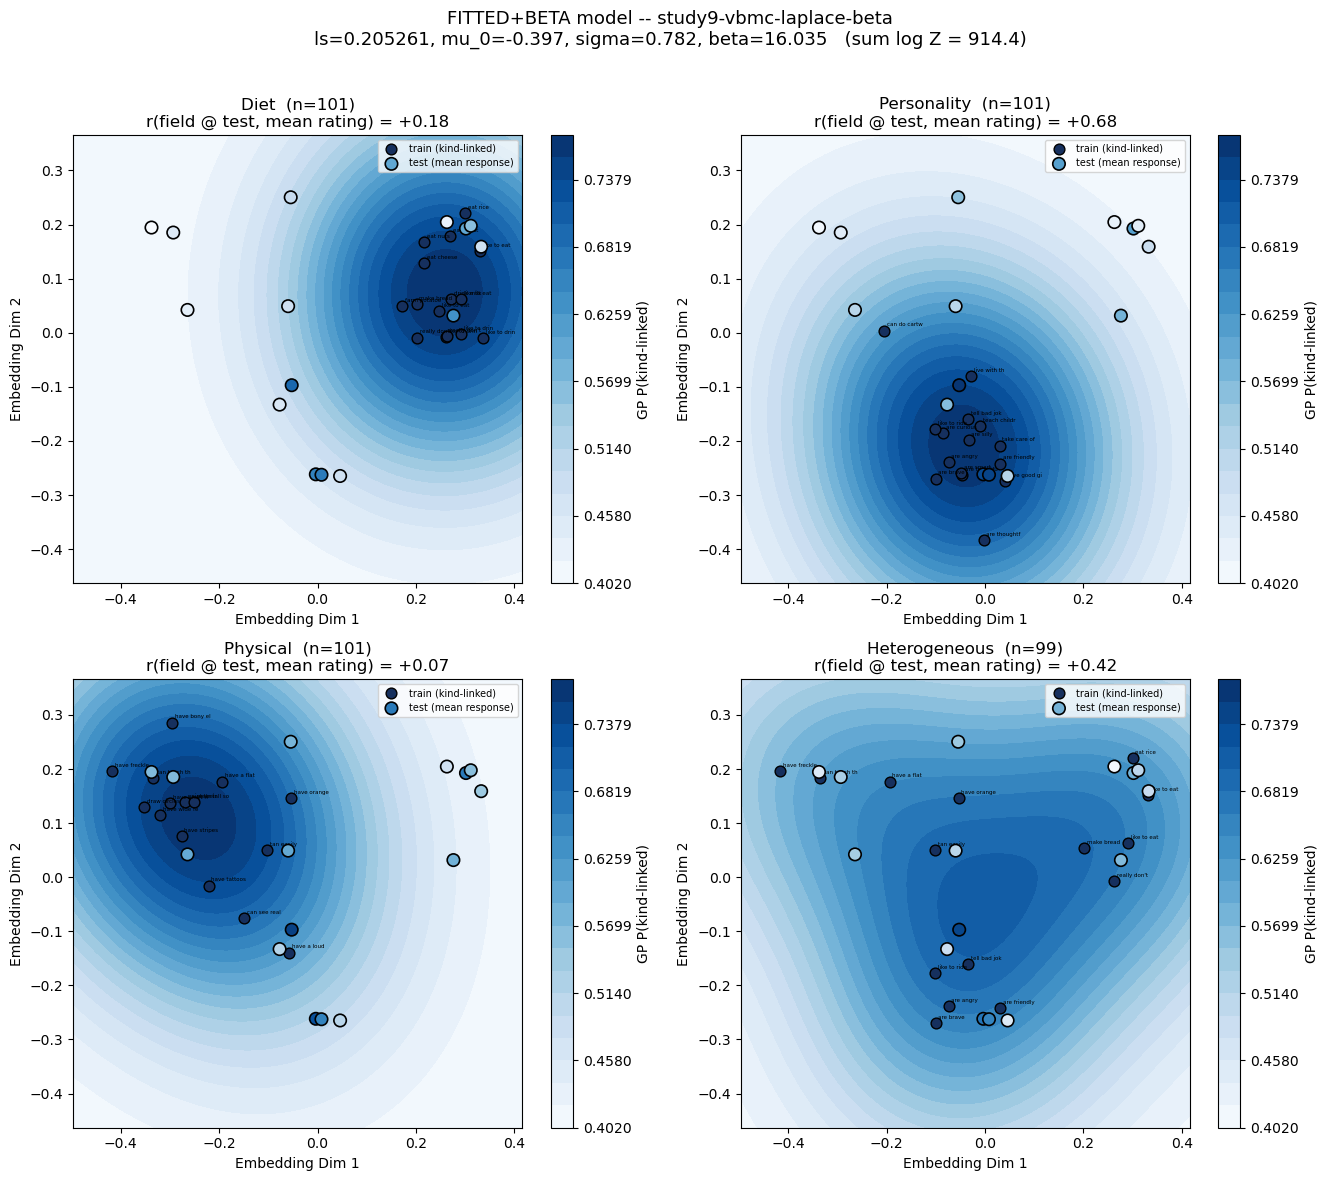

saved results/study9-vbmc-laplace/gp-coherence-field-comparison.png


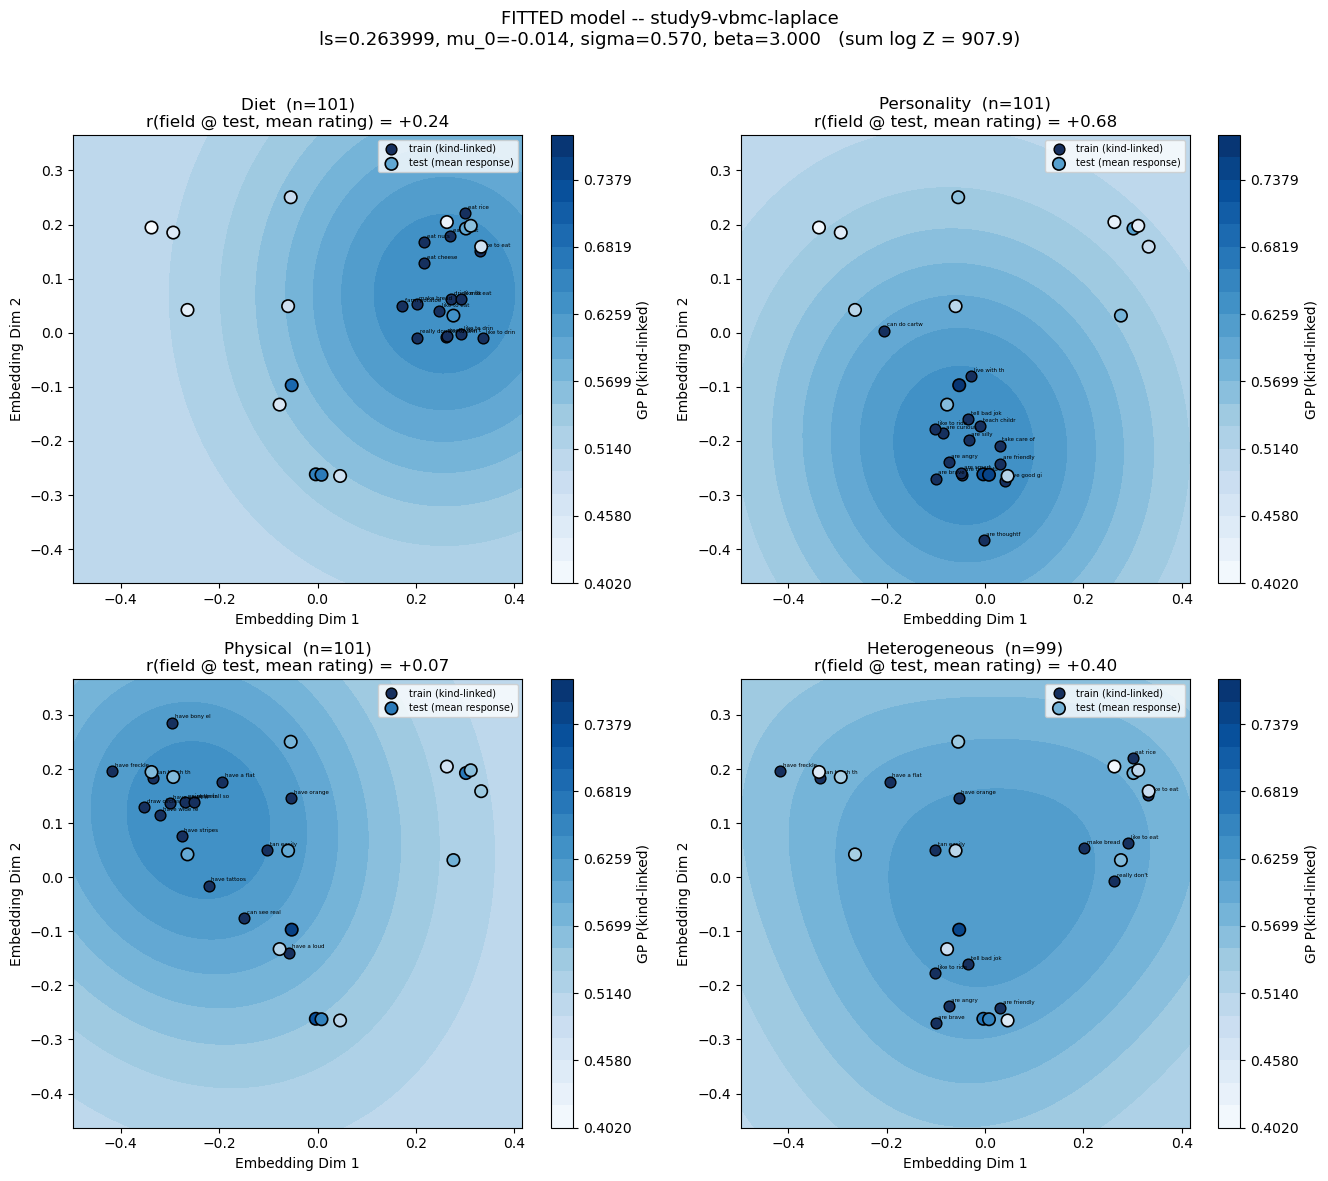

saved results/study9-vbmc-laplace-null-beta/gp-coherence-field-comparison.png


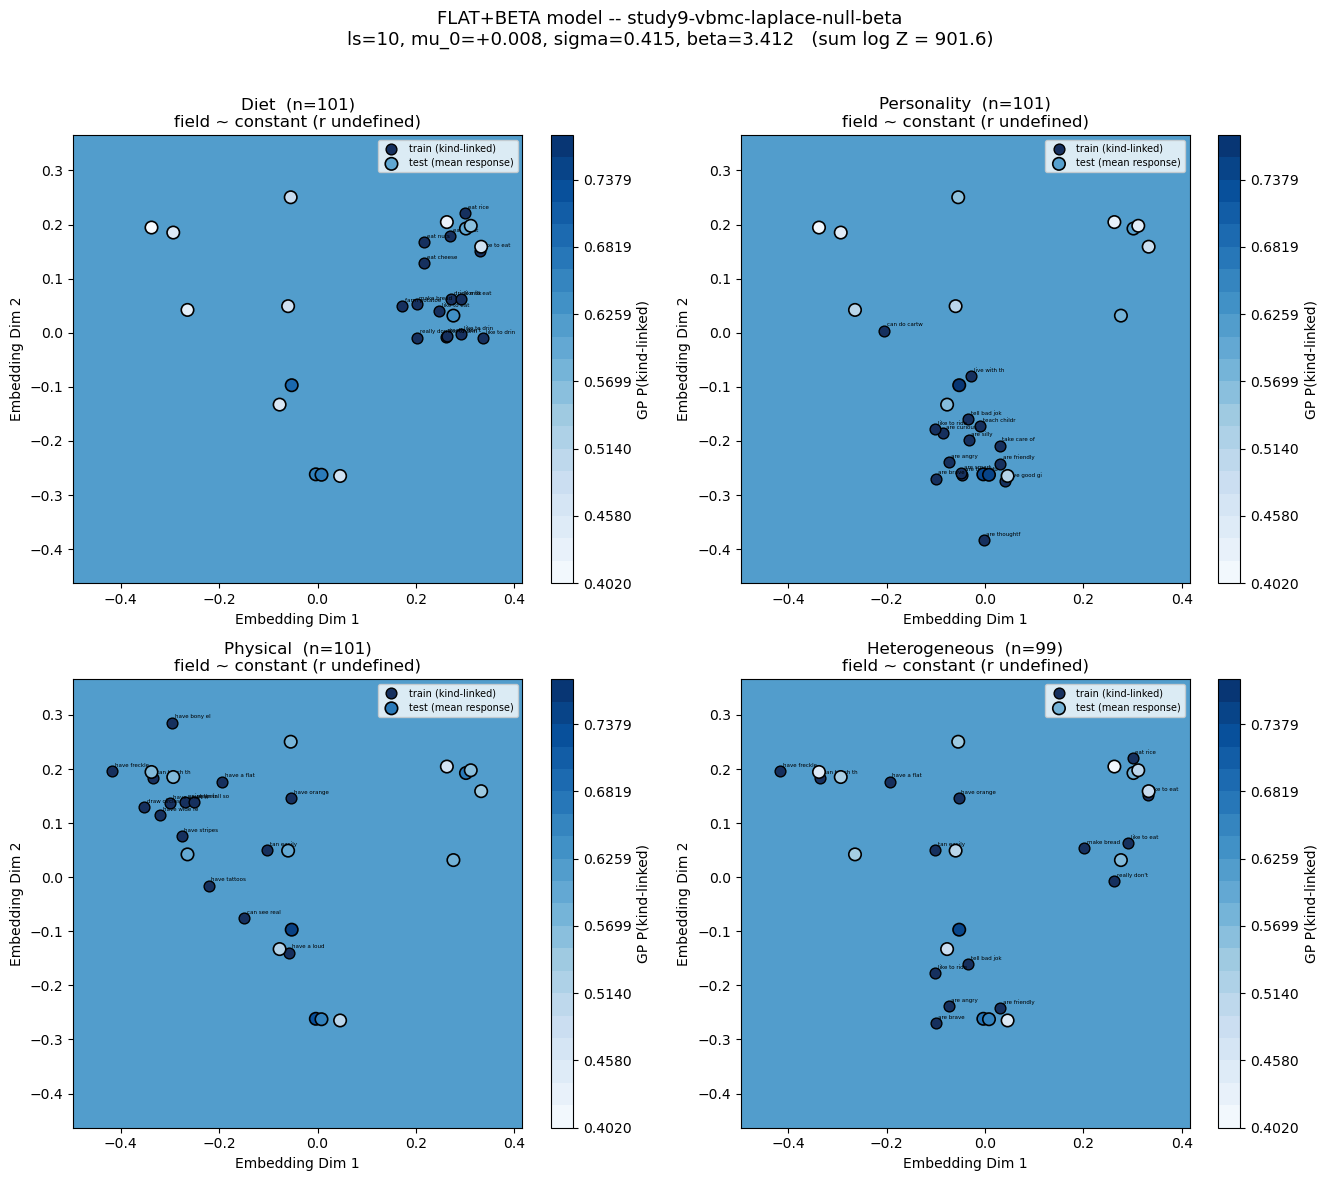

saved results/study9-vbmc-laplace-null/gp-coherence-field-comparison.png


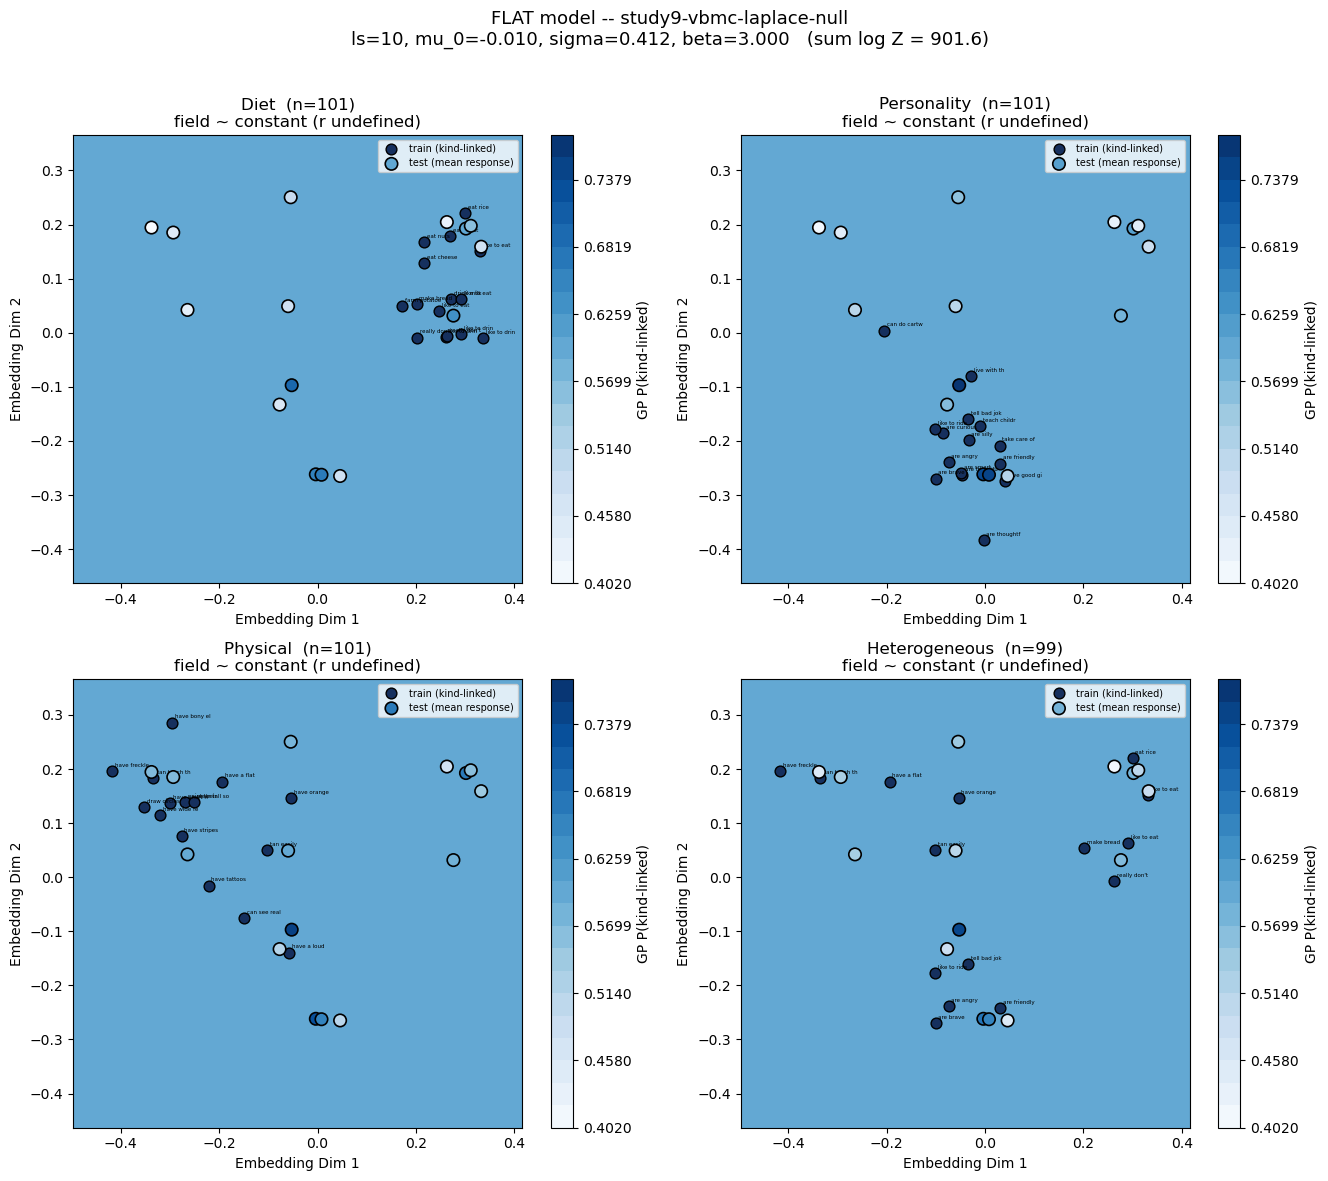

In [6]:
for name, m in MODELS.items():
    plot_fields(name, m)

## 4. Predicted vs empirical prevalence per feature

The forward-pass scatter used in the per-model notebooks (`model-study9-vbmc-laplace*.ipynb`): one
row of four condition-panels per model, each point a test feature colored by its trait
(diet / personality / physical), with the matched-condition trait outlined in black. `x` is the
empirical mean rating, `y` is the model's `E[rating]`; the dashed line is the identity. Panel
subtitles give per-condition r; the row title gives the pooled r across all conditions.

saved results/predicted-vs-empirical-scatter-comparison.png


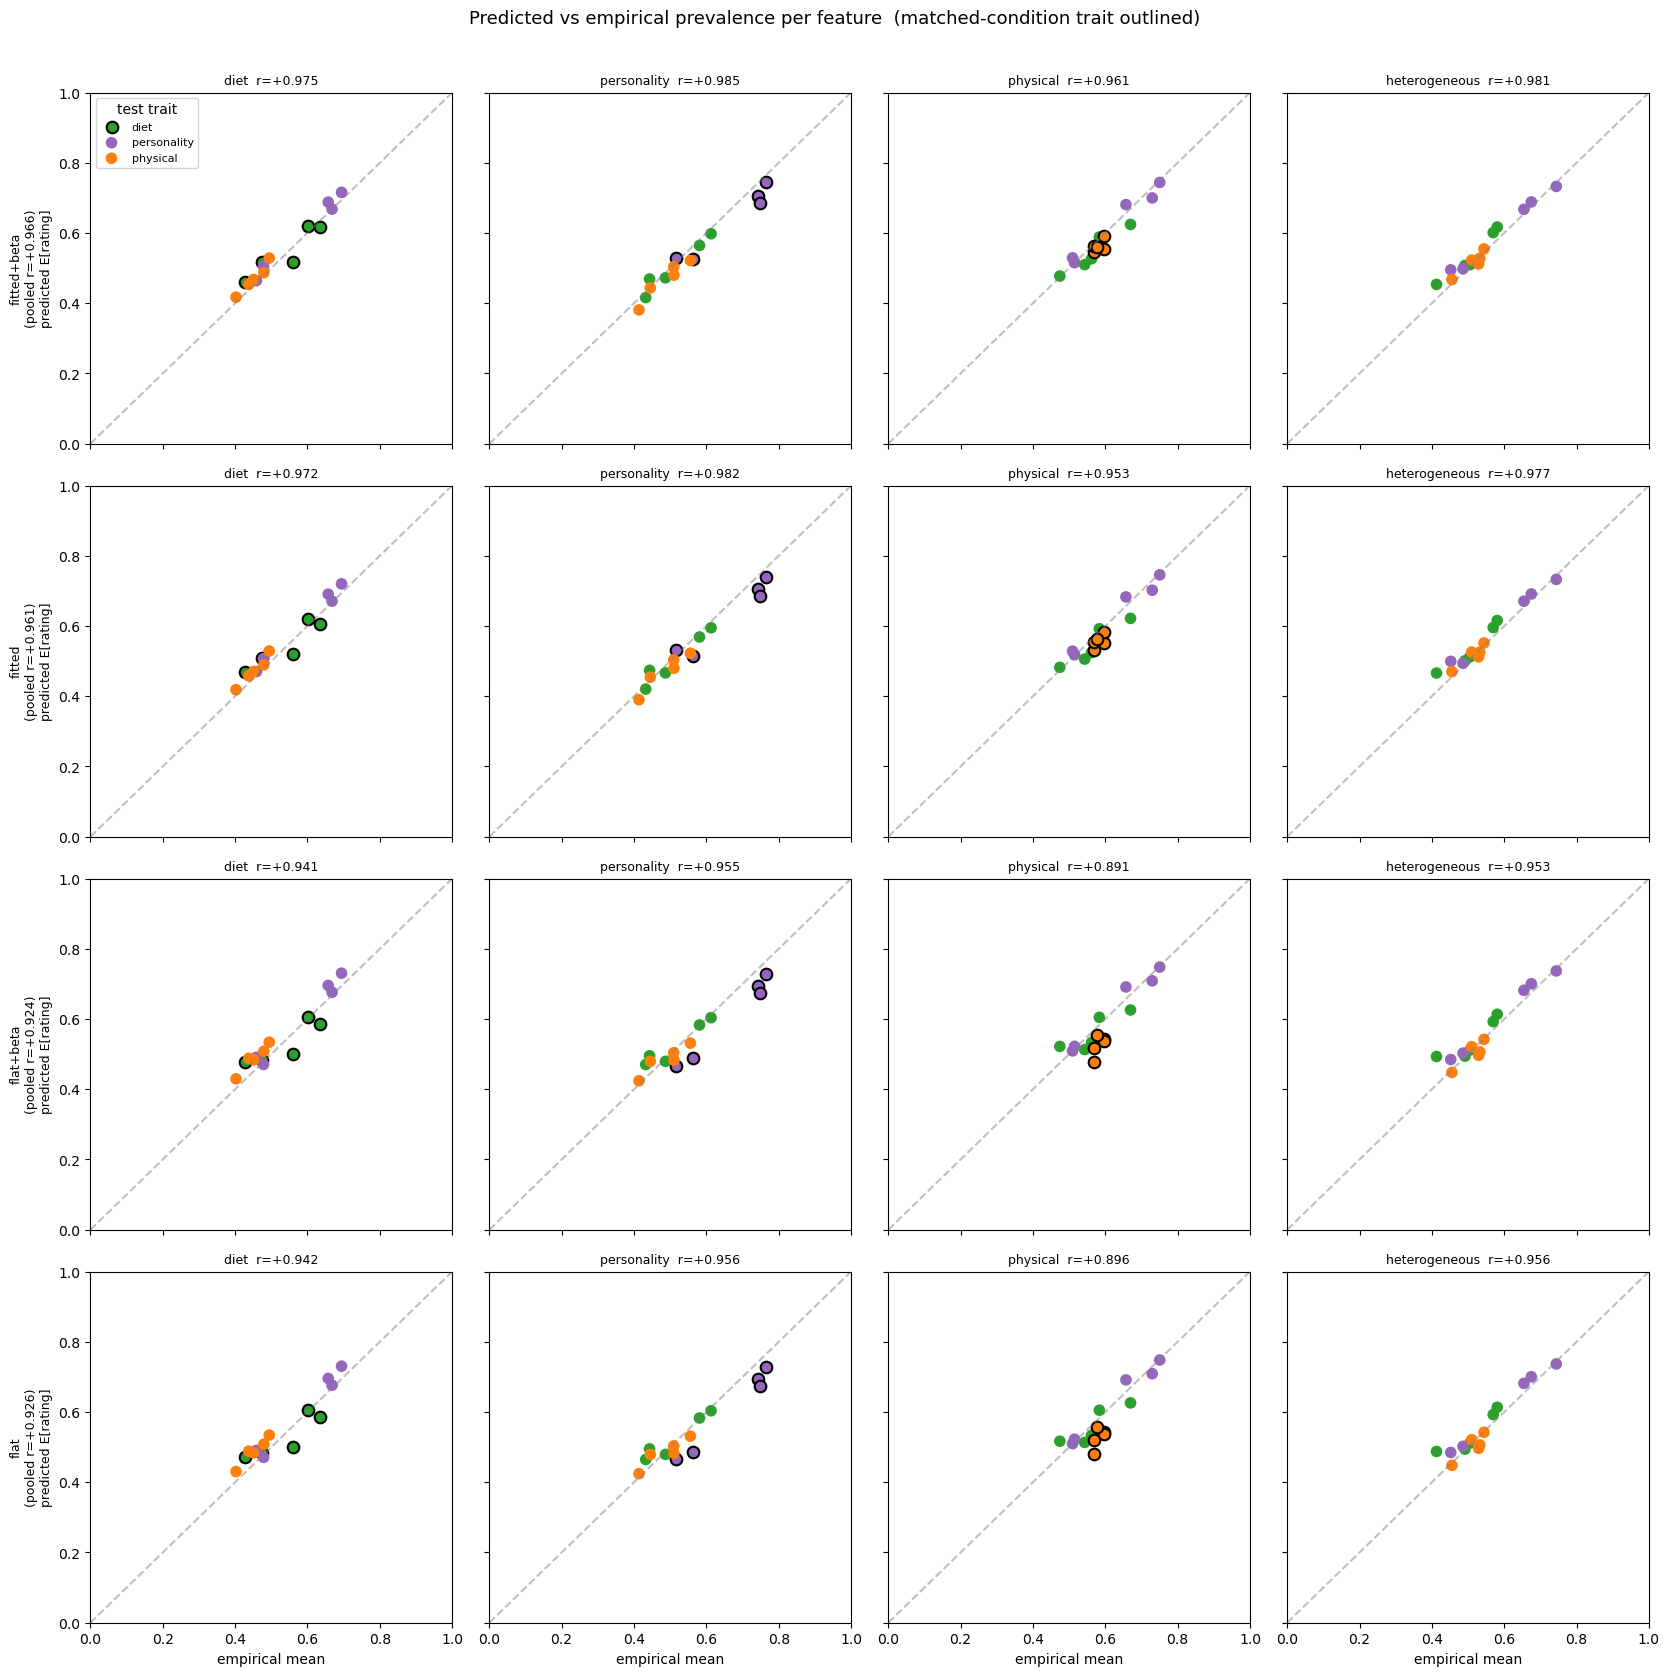

In [7]:
traits = np.array(test_trait)
tcolor = {'diet': 'tab:green', 'personality': 'tab:purple', 'physical': 'tab:orange'}

# one row of 4 condition-panels per model, all sharing axes
fig, axgrid = plt.subplots(len(MODELS), len(inf.CONDITIONS),
                           figsize=(4.2*len(inf.CONDITIONS), 4.2*len(MODELS)),
                           sharex=True, sharey=True)
for row, (name, m) in enumerate(MODELS.items()):
    pred_cond = fitres[name]['pred_cond']
    for col, c in enumerate(inf.CONDITIONS):
        ax = axgrid[row, col]
        for tr in tcolor:
            mask = traits == tr
            ax.scatter(emp_cond[c][mask], pred_cond[c][mask], s=70, color=tcolor[tr],
                       edgecolor=('k' if tr == c else 'none'), linewidth=1.5,
                       label=tr if (row == 0 and col == 0) else None)
        ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        r = np.corrcoef(pred_cond[c], emp_cond[c])[0, 1]
        ax.set_title(f"{c}  r={r:+.3f}", fontsize=9)
        if col == 0:
            r_pool_row = np.corrcoef(np.concatenate([pred_cond[cc] for cc in inf.CONDITIONS]),
                                     emp_all)[0, 1]
            ax.set_ylabel(f"{name}\n(pooled r={r_pool_row:+.3f})\npredicted E[rating]", fontsize=9)
        if row == len(MODELS) - 1:
            ax.set_xlabel('empirical mean')
axgrid[0, 0].legend(fontsize=8, title='test trait', loc='upper left')
fig.suptitle('Predicted vs empirical prevalence per feature  (matched-condition trait outlined)',
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
out_png = os.path.join('results', 'predicted-vs-empirical-scatter-comparison.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print('saved', out_png)
plt.show()